# 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 2. Configuration

In [23]:
FEATURE_COLS = [
    "cpuUsage",
    "ramUsage",
    "networkConnections",
    "processCount",
    "cpuPackagePower",
    "cpuAverageClock",
    "cpuTemperature"
]

TEMP_COL = "cpuTemperature"

LOOKBACK = 20
PREDICTION_HORIZON = 30
BATCH_SIZE = 32
INTERLEAVE_BATCH = 32  # batch size for interleaving master sets

CSV_FILES = ["prabhsimrat_logs.csv", "sushant_logs.csv", "manan_logs.csv"]

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

SEED = 42

# 3. Load Data

In [6]:
raw_dfs = {}
for csv_file in CSV_FILES:
    raw_dfs[csv_file] = pd.read_csv(csv_file)
    print(f"Loaded {csv_file}: {len(raw_dfs[csv_file])} rows")

Loaded prabhsimrat_logs.csv: 16361 rows
Loaded sushant_logs.csv: 16093 rows
Loaded manan_logs.csv: 20239 rows


# 4. Clean Data

In [7]:
def clean_data(df):
    df = df.copy()
    required_cols = list(set(FEATURE_COLS))
    df = df.dropna(subset=required_cols)
    df = df.reset_index(drop=True)
    return df

In [8]:
clean_dfs = {}
for csv_file in CSV_FILES:
    clean_dfs[csv_file] = clean_data(raw_dfs[csv_file])
    print(f"Cleaned {csv_file}: {len(clean_dfs[csv_file])} rows")

Cleaned prabhsimrat_logs.csv: 16361 rows
Cleaned sushant_logs.csv: 16093 rows
Cleaned manan_logs.csv: 20239 rows


# 5. Split Each CSV Chronologically (80% Train / 10% Val / 10% Test)

Each CSV is split independently to preserve temporal ordering within each source.

In [9]:
split_data = {}  # {csv_file: {'train': df, 'val': df, 'test': df}}

for csv_file, df in clean_dfs.items():
    n = len(df)
    train_end = int(n * TRAIN_RATIO)
    val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

    df_train = df.iloc[:train_end].copy()
    df_val   = df.iloc[train_end:val_end].copy()
    df_test  = df.iloc[val_end:].copy()

    split_data[csv_file] = {
        "train": df_train,
        "val":   df_val,
        "test":  df_test
    }

    print(f"\n{csv_file}:")
    print(f"  Train: {len(df_train)} rows ({len(df_train)/n*100:.1f}%)")
    print(f"  Val:   {len(df_val)} rows ({len(df_val)/n*100:.1f}%)")
    print(f"  Test:  {len(df_test)} rows ({len(df_test)/n*100:.1f}%)")


prabhsimrat_logs.csv:
  Train: 13088 rows (80.0%)
  Val:   1636 rows (10.0%)
  Test:  1637 rows (10.0%)

sushant_logs.csv:
  Train: 12874 rows (80.0%)
  Val:   1609 rows (10.0%)
  Test:  1610 rows (10.0%)

manan_logs.csv:
  Train: 16191 rows (80.0%)
  Val:   2024 rows (10.0%)
  Test:  2024 rows (10.0%)


# 6. Fit Scaler on Combined Training Data

The scaler is fit on the **combined** 80% training portions from all 3 CSVs, so that
the normalization statistics reflect the full diversity of the training data.

In [10]:
# Concatenate all training portions
all_train_dfs = [split_data[f]['train'] for f in CSV_FILES]
combined_train_features = pd.concat(
    [df[FEATURE_COLS] for df in all_train_dfs],
    ignore_index=True
)

scaler_X = StandardScaler()
scaler_X.fit(combined_train_features)

print(f"Scaler fitted on {len(combined_train_features)} combined training rows")
print(f"Mean: {scaler_X.mean_}")
print(f"Scale: {scaler_X.scale_}")

Scaler fitted on 42153 combined training rows
Mean: [  55.92278604   73.23841909  193.97179323  309.13356108   32.48966859
 2879.23525253   85.84218917]
Scale: [ 32.97270898   9.42013195  36.1691449   29.71345453  14.26130726
 657.24919522  11.99244772]


# 7. Create Sequences Function

This function is **unchanged** from the original notebook.
For each index `i` from `lookback` to `len(df)`, it creates:
- A window `[i-lookback : i]` of scaled features → shape `(lookback, n_features)`
- Target `y = temperature[i] - temperature[i-1]` (delta from last timestep to next)

In [22]:
def create_sequences(
    df,
    scaler,
    lookback,
    horizon
):

    feature_data = df.loc[
        :,
        FEATURE_COLS
    ].copy()

    scaled_features = scaler.transform(
        feature_data
    )

    temperatures = df[
        TEMP_COL
    ].to_numpy()

    X = []
    y_delta = []
    current_temps = []
    actual_future_temps = []

    last_index = (
        len(df) - horizon + 1
    )

    for i in range(
        lookback,
        last_index
    ):

        # Previous sensor history
        sequence = scaled_features[
            i - lookback:i
        ]

        # Temperature at prediction time
        current_temp = temperatures[i - 1]

        # Temperature HORIZON steps later
        future_temp = temperatures[
            i + horizon - 1
        ]

        # Change over the entire future horizon
        delta_temp = (
            future_temp - current_temp
        )

        X.append(sequence)

        y_delta.append(
            delta_temp
        )

        current_temps.append(
            current_temp
        )

        actual_future_temps.append(
            future_temp
        )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y_delta, dtype=np.float32),
        np.asarray(current_temps, dtype=np.float32),
        np.asarray(
            actual_future_temps,
            dtype=np.float32
        )
    )

# 8. Create Sequences for Each Split

We create sequences independently for each CSV's train/val/test portion.
This preserves temporal contiguity within each lookback window.

In [24]:
# Store sequences per csv per split: {csv_file: {'train': (X, y, ct, at), ...}}
sequences = {}

for csv_file in CSV_FILES:
    sequences[csv_file] = {}
    for split_name in ["train", "val", "test"]:
        df_split = split_data[csv_file][split_name]
        if len(df_split) <= LOOKBACK:
            print(f'WARNING: {csv_file} {split_name} has only {len(df_split)} rows, '
                  f'skipping (need > {LOOKBACK})')
            sequences[csv_file][split_name] = None
            continue
        X, y_d, ct, at = create_sequences(df_split, scaler_X, LOOKBACK, PREDICTION_HORIZON)
        sequences[csv_file][split_name] = (X, y_d, ct, at)
        print(f"{csv_file} | {split_name:5s} | X: {X.shape}, y: {y_d.shape}")

prabhsimrat_logs.csv | train | X: (13039, 20, 7), y: (13039,)
prabhsimrat_logs.csv | val   | X: (1587, 20, 7), y: (1587,)
prabhsimrat_logs.csv | test  | X: (1588, 20, 7), y: (1588,)
sushant_logs.csv | train | X: (12825, 20, 7), y: (12825,)
sushant_logs.csv | val   | X: (1560, 20, 7), y: (1560,)
sushant_logs.csv | test  | X: (1561, 20, 7), y: (1561,)
manan_logs.csv | train | X: (16142, 20, 7), y: (16142,)
manan_logs.csv | val   | X: (1975, 20, 7), y: (1975,)
manan_logs.csv | test  | X: (1975, 20, 7), y: (1975,)


# 9. Build Master Sets via Batch-wise Interleaving

For each split (train/val/test), we randomly pick one of the 3 source CSVs,
take a contiguous batch of sequences from it, and append to the master set.
This is repeated until all sequences from all sources are consumed.
The result is a generalised dataset that interleaves data from all 3 laptops.

In [25]:
def build_master_set(sequence_dict, split_name, batch_size=32, seed=42):
    """
    Interleave sequences from multiple sources batch-wise.

    Parameters
    ----------
    sequence_dict : dict
        {csv_file: {'train': (X, y, ct, at), 'val': ..., 'test': ...}}
    split_name : str
        One of "train", "val", "test"
    batch_size : int
        Number of contiguous sequences to take per batch from a source
    seed : int
        Random seed for reproducibility

    Returns
    -------
    X_master, y_master, ct_master, at_master : np.ndarray
    """
    rng = np.random.RandomState(seed)

    # Collect available sources and their cursors
    sources = []
    for csv_file in CSV_FILES:
        seq = sequence_dict[csv_file].get(split_name)
        if seq is not None:
            X, y_d, ct, at = seq
            sources.append({
                "name": csv_file,
                "X": X, "y": y_d, "ct": ct, "at": at,
                "cursor": 0,
                "total": len(X)
            })

    X_parts = []
    y_parts = []
    ct_parts = []
    at_parts = []

    # Keep going until all sources are exhausted
    while True:
        # Find sources that still have data
        active = [s for s in sources if s["cursor"] < s["total"]]
        if not active:
            break

        # Randomly pick one active source
        src = active[rng.randint(len(active))]

        start = src["cursor"]
        end = min(start + batch_size, src["total"])

        X_parts.append(src["X"][start:end])
        y_parts.append(src["y"][start:end])
        ct_parts.append(src["ct"][start:end])
        at_parts.append(src["at"][start:end])

        src["cursor"] = end

    X_master = np.concatenate(X_parts, axis=0)
    y_master = np.concatenate(y_parts, axis=0)
    ct_master = np.concatenate(ct_parts, axis=0)
    at_master = np.concatenate(at_parts, axis=0)

    return X_master, y_master, ct_master, at_master

In [26]:
# Build master train, val, test sets
X_train, y_train, ct_train, at_train = build_master_set(
    sequences, "train", batch_size=INTERLEAVE_BATCH, seed=SEED
)
X_val, y_val, ct_val, at_val = build_master_set(
    sequences, "val", batch_size=INTERLEAVE_BATCH, seed=SEED
)
X_test, y_test, ct_test, at_test = build_master_set(
    sequences, "test", batch_size=INTERLEAVE_BATCH, seed=SEED
)

print("=== Master Set Shapes ===")
print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Val:   X={X_val.shape},   y={y_val.shape}")
print(f"Test:  X={X_test.shape},  y={y_test.shape}")

=== Master Set Shapes ===
Train: X=(42006, 20, 7), y=(42006,)
Val:   X=(5122, 20, 7),   y=(5122,)
Test:  X=(5124, 20, 7),  y=(5124,)


# 10. Build Model

Architecture is **unchanged**: LSTM(64) → Dropout(0.2) → LSTM(32) → Dropout(0.2) → Dense(16, relu) → Dense(1)

In [27]:
model = Sequential([

    Input(
        shape=(LOOKBACK, len(FEATURE_COLS))
    ),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(
        16,
        activation="relu"
    ),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

# 11. Callbacks

In [28]:
early_stopping = EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6
)

# 12. Train Model

In [29]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, reduce_lr],
    shuffle=False
)

Epoch 1/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 78.3580 - mae: 5.6091 - val_loss: 104.3739 - val_mae: 6.4571 - learning_rate: 0.0010
Epoch 2/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 67.7430 - mae: 5.5549 - val_loss: 101.3836 - val_mae: 6.7048 - learning_rate: 0.0010
Epoch 3/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 63.5171 - mae: 5.4723 - val_loss: 98.7316 - val_mae: 6.7390 - learning_rate: 0.0010
Epoch 4/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 61.5049 - mae: 5.4123 - val_loss: 98.7506 - val_mae: 6.7937 - learning_rate: 0.0010
Epoch 5/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 58.9938 - mae: 5.2937 - val_loss: 97.8264 - val_mae: 6.6499 - learning_rate: 0.0010
Epoch 6/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 58.5922 - mae: 5.2497 - val_loss: 94.8038 - val_mae: 6.5500 - learning_rate: 0.0010
Epoch 7/100
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 57.2716 - mae: 5.1959 - val_loss: 93.7795 - val_mae: 

# 13. Training History

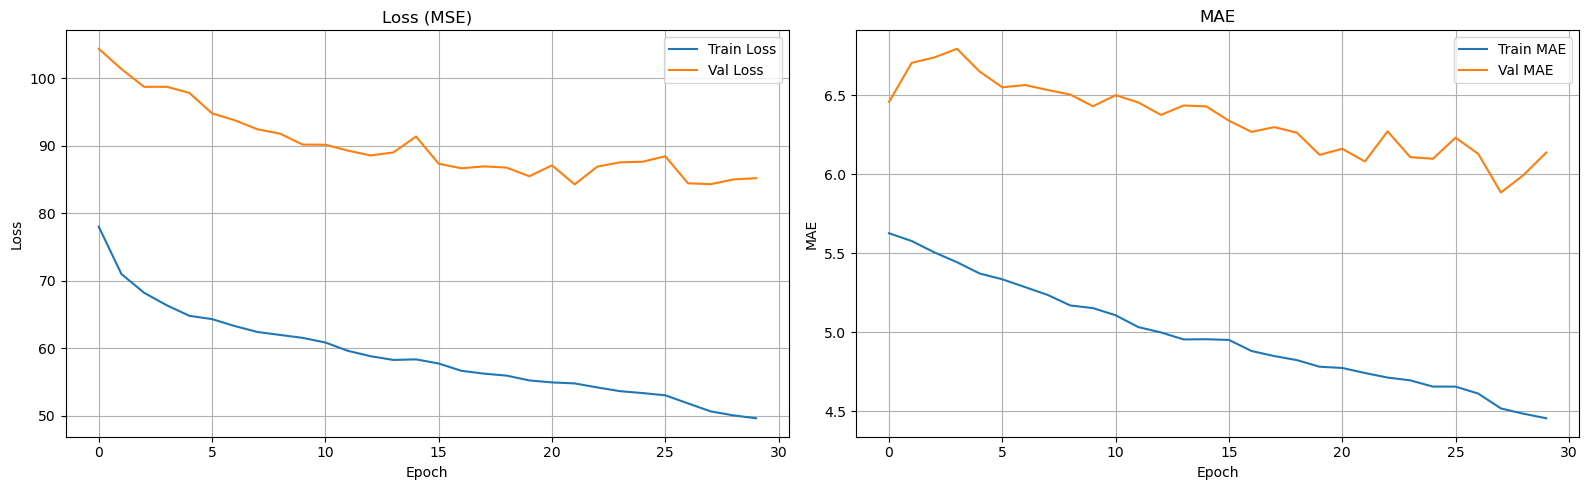

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# MAE
axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 14. Save Model, Scaler & Config

In [31]:
import joblib
import json

# 1. Save trained model
model.save("cpu_temperature_delta_model.keras")

# 2. Save fitted scaler
joblib.dump(
    scaler_X,
    "cpu_feature_scaler.pkl"
)

# 3. Save model configuration
config = {
    "feature_cols": FEATURE_COLS,
    "temp_col": TEMP_COL,
    "lookback": LOOKBACK
}

with open("model_config.json", "w") as f:
    json.dump(config, f, indent=4)

print("=================================")
print("Everything saved successfully!")
print("=================================")
print("Model:  cpu_temperature_delta_model.keras")
print("Scaler: cpu_feature_scaler.pkl")
print("Config: model_config.json")

Everything saved successfully!
Model:  cpu_temperature_delta_model.keras
Scaler: cpu_feature_scaler.pkl
Config: model_config.json


# 15. Evaluation Function

In [32]:
def evaluate_model(model, X, y_delta, current_temps, actual_temps, name):
    """Evaluate model on pre-built sequences."""

    predicted_delta = model.predict(X).flatten()

    # Reconstruct actual temperature
    predicted_temps = current_temps + predicted_delta

    mae = mean_absolute_error(actual_temps, predicted_temps)
    rmse = np.sqrt(mean_squared_error(actual_temps, predicted_temps))
    r2 = r2_score(actual_temps, predicted_temps)

    print(f"\n===== {name} =====")
    print(f"MAE:  {mae:.2f} °C")
    print(f"RMSE: {rmse:.2f} °C")
    print(f"R²:   {r2:.4f}")

    return predicted_temps, actual_temps, mae, rmse, r2

# 16. Evaluate on Master Test Set

In [33]:
pred_temps, act_temps, mae, rmse, r2 = evaluate_model(
    model, X_test, y_test, ct_test, at_test,
    "Master Test Set (All 3 CSVs)"
)

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

===== Master Test Set (All 3 CSVs) =====
MAE:  5.32 °C
RMSE: 7.79 °C
R²:   0.3108


# 17. Master Test Set — Prediction Plot

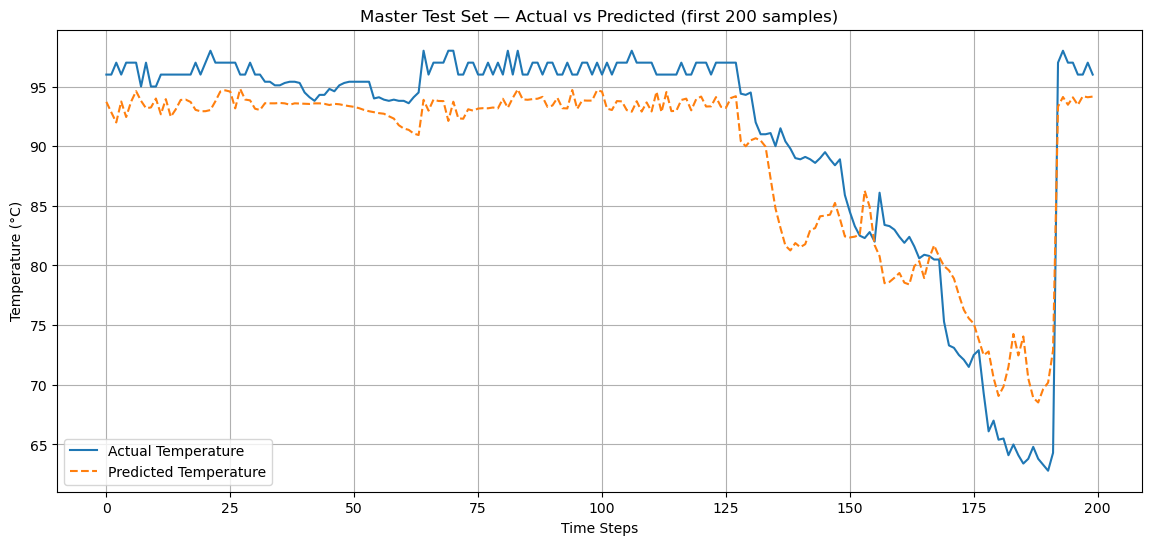

In [34]:
plt.figure(figsize=(14, 6))

plt.plot(
    act_temps[:200],
    label="Actual Temperature"
)

plt.plot(
    pred_temps[:200],
    "--",
    label="Predicted Temperature"
)

plt.title("Master Test Set — Actual vs Predicted (first 200 samples)")
plt.xlabel("Time Steps")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

# 18. Per-Source Evaluation on Test Split

Evaluate the model separately on each CSV's test portion to see how it
generalises across different laptops.

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== Test: prabhsimrat_logs.csv =====
MAE:  8.40 °C
RMSE: 10.89 °C
R²:   0.0975


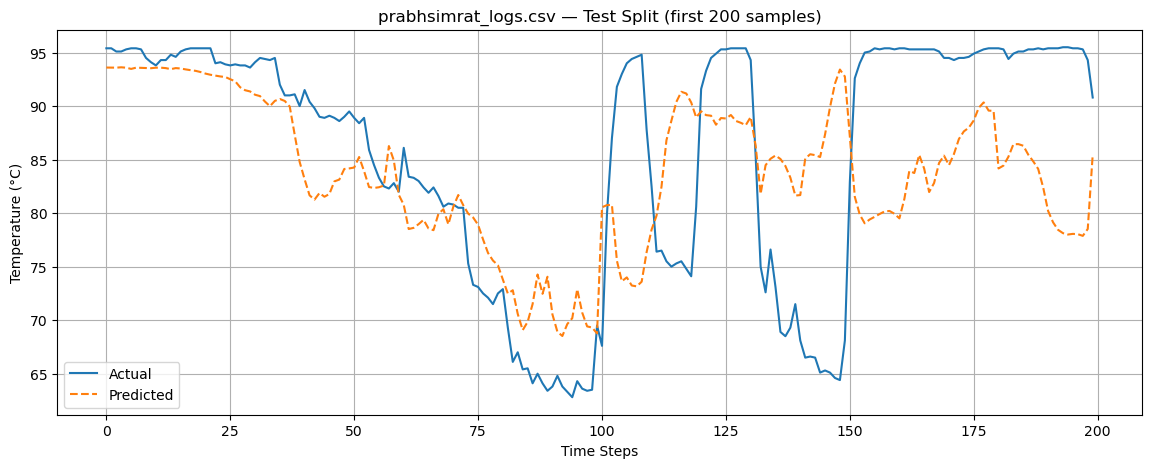

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

===== Test: sushant_logs.csv =====
MAE:  2.36 °C
RMSE: 2.67 °C
R²:   -4.3402


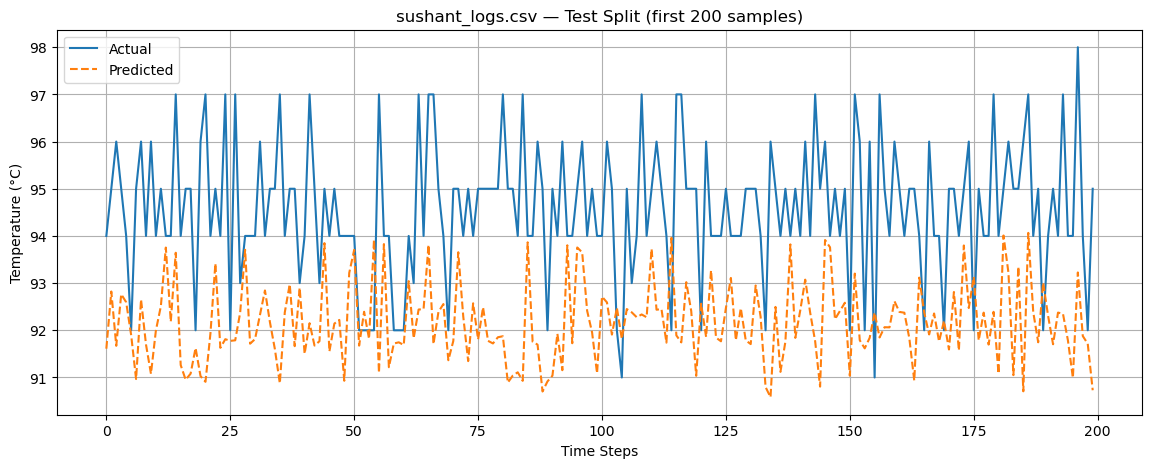

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

===== Test: manan_logs.csv =====
MAE:  5.19 °C
RMSE: 7.51 °C
R²:   0.3642


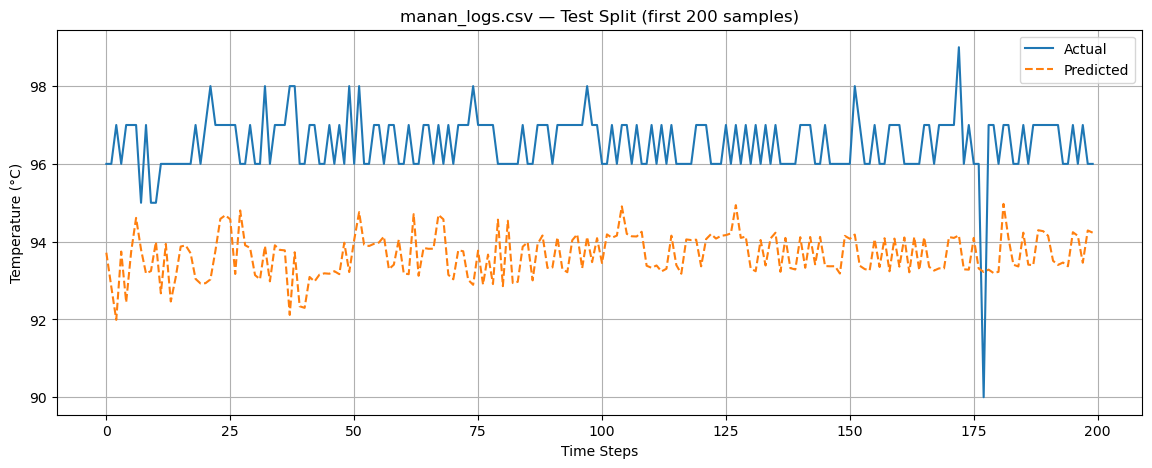

In [35]:
for csv_file in CSV_FILES:
    seq = sequences[csv_file].get('test')
    if seq is None:
        print(f"\nSkipping {csv_file} — not enough test data")
        continue
    X_src, y_src, ct_src, at_src = seq
    pred_src, act_src, mae_src, rmse_src, r2_src = evaluate_model(
        model, X_src, y_src, ct_src, at_src, f"Test: {csv_file}"
    )

    plt.figure(figsize=(14, 5))
    plt.plot(act_src[:200], label="Actual")
    plt.plot(pred_src[:200], "--", label="Predicted")
    plt.title(f"{csv_file} — Test Split (first 200 samples)")
    plt.xlabel("Time Steps")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True)
    plt.show()

In [36]:
for csv_file in CSV_FILES:

    X_src, y_src, ct_src, at_src = sequences[csv_file]["test"]

    pred_delta = model.predict(
        X_src,
        verbose=0
    ).flatten()

    pred_temp = ct_src + pred_delta

    print(f"\n{'=' * 50}")
    print(csv_file)
    print(f"{'=' * 50}")

    print(f"Actual min:  {at_src.min():.2f} °C")
    print(f"Actual max:  {at_src.max():.2f} °C")
    print(f"Actual range:{np.ptp(at_src):.2f} °C")
    print(f"Actual std:  {np.std(at_src):.2f} °C")

    print(f"\nPredicted min:  {pred_temp.min():.2f} °C")
    print(f"Predicted max:  {pred_temp.max():.2f} °C")
    print(f"Predicted std:  {np.std(pred_temp):.2f} °C")

    print(f"\nActual mean:    {np.mean(at_src):.2f} °C")
    print(f"Predicted mean: {np.mean(pred_temp):.2f} °C")


prabhsimrat_logs.csv
Actual min:  0.00 °C
Actual max:  95.60 °C
Actual range:95.60 °C
Actual std:  11.46 °C

Predicted min:  30.90 °C
Predicted max:  102.15 °C
Predicted std:  6.92 °C

Actual mean:    85.48 °C
Predicted mean: 85.03 °C

sushant_logs.csv
Actual min:  87.00 °C
Actual max:  98.00 °C
Actual range:11.00 °C
Actual std:  1.16 °C

Predicted min:  89.57 °C
Predicted max:  95.14 °C
Predicted std:  0.77 °C

Actual mean:    94.57 °C
Predicted mean: 92.30 °C

manan_logs.csv
Actual min:  67.00 °C
Actual max:  99.00 °C
Actual range:32.00 °C
Actual std:  9.41 °C

Predicted min:  70.33 °C
Predicted max:  95.83 °C
Predicted std:  7.17 °C

Actual mean:    90.07 °C
Predicted mean: 88.30 °C


In [37]:
for csv_file in CSV_FILES:

    X_src, y_src, ct_src, at_src = sequences[csv_file]["test"]

    # Model prediction
    pred_delta = model.predict(
        X_src,
        verbose=0
    ).flatten()

    model_pred = ct_src + pred_delta

    # Persistence prediction:
    # assume next temperature stays the same
    persistence_pred = ct_src

    # Model metrics
    model_mae = mean_absolute_error(
        at_src,
        model_pred
    )

    model_rmse = np.sqrt(
        mean_squared_error(
            at_src,
            model_pred
        )
    )

    # Persistence metrics
    persistence_mae = mean_absolute_error(
        at_src,
        persistence_pred
    )

    persistence_rmse = np.sqrt(
        mean_squared_error(
            at_src,
            persistence_pred
        )
    )

    print(f"\n===== {csv_file} =====")

    print("\nLSTM:")
    print(f"MAE:  {model_mae:.3f}")
    print(f"RMSE: {model_rmse:.3f}")

    print("\nPersistence baseline:")
    print(f"MAE:  {persistence_mae:.3f}")
    print(f"RMSE: {persistence_rmse:.3f}")

    improvement = (
        (persistence_mae - model_mae)
        / persistence_mae
        * 100
    )

    print(
        f"\nMAE improvement over persistence: "
        f"{improvement:.2f}%"
    )


===== prabhsimrat_logs.csv =====

LSTM:
MAE:  8.396
RMSE: 10.888

Persistence baseline:
MAE:  10.166
RMSE: 14.451

MAE improvement over persistence: 17.41%

===== sushant_logs.csv =====

LSTM:
MAE:  2.362
RMSE: 2.669

Persistence baseline:
MAE:  1.167
RMSE: 1.661

MAE improvement over persistence: -102.48%

===== manan_logs.csv =====

LSTM:
MAE:  5.192
RMSE: 7.505

Persistence baseline:
MAE:  4.185
RMSE: 7.964

MAE improvement over persistence: -24.07%
